# **CS 224 Final Project**


This project aims to identify sequences of bat chirps which occur frequently in bat communication so that biologists might be able to discern contextual meaning from recordings of bats in the wild.

This project analyzes 41,774 bat chirps from 2929 different recordings collected from an outdoor microphone at Jasper Ridge Biological Preserve between 01/02/2022 and 02/09/2022, and uses Graph Attention Transformers and HDBSCAN to identify clusters of acoustically similar chirp sequences.



In [1]:
!pip install torch_geometric

import pandas as pd
import torch
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from torch_geometric.data import Data

/opt/anaconda3/envs/BatGPT/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# 1. Data Preprocessing


### **Data Cleaning**
First, we clean the data and remove irrelevant or non-numerical columns. We remove most amplitude related features because the amplitude of a chirp says more about how close the bat was to the microphone when it uttered the chirp than it does about intrinsic acoustic properties of the chirp. We keep amplitude features such as variance and skew in order to preserve relative measures of amplitude.

In [2]:

#Import data
df = pd.read_csv('Files_above_length_8.csv')

# Define columns to remove directly
columns_to_remove_direct = ['Path', 'Filename', 'TimeInFile', 'ParentDir', 'NextDirUp', 'Version', 'Filter']

# Identify columns with 'Amp' in their names, excluding the specified ones
keep = ["AmpVariance", "AmpKurtosis", "AmpSkew", "AmpGausR2"]
amp_columns = [col for col in df.columns if 'Amp' in col and col not in keep]

# Remove columns
all_columns_to_remove = list(set(columns_to_remove_direct + amp_columns))
df = df.drop(columns=all_columns_to_remove, errors='ignore')

kept_columns = list(df.columns)
#print(f"Kept columns: {kept_columns}")

print(df.shape)


(41774, 85)


### **PCA**
Next, we normalize our features and perform PCA to reduce the number of dimensions from 85 to 32. This explains 92.55% of the variance.

In [3]:
# Exclude 'FileID' and 'PrecedingIntrvl' columns from features before scaling and PCA
df_features = df.drop(columns=['FileID', 'PrecedingIntrvl'])

# Normalize the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_features)

# Perform PCA with 32 components
pca = PCA(n_components=32)
pca.fit(scaled_data)

# Print explained variance
explained_variance = np.sum(pca.explained_variance_ratio_)
print(f"Total variance explained by 32 components: {explained_variance:.4f}")

#Create new dataframe with PCA features
pca_features = pca.transform(scaled_data)
pca_columns = [f'PC{i+1}' for i in range(pca_features.shape[1])]
df_pca_features = pd.DataFrame(data=pca_features, columns=pca_columns)

#Combine PCA with FileID and PrecedingIntrvl for grouping and edge features
df_original_metadata = df[['FileID', 'PrecedingIntrvl']]
df_pca = pd.concat([df_original_metadata, df_pca_features], axis=1)
print("Shape of df_pca:", df_pca.shape)
#print("First 5 rows of df_pca:")
#print(df_pca.head())

Total variance explained by 32 components: 0.9341
Shape of df_pca: (41774, 34)


### **Make Graphs for each Recording**

For each FileId, we create a **bidirectional** graph with PCA features for each chirp as node features. Edge features use `log(1 + Δt)` transformed time intervals, normalized globally across all recordings. Bidirectional edges allow context to flow both forward and backward in time, which helps create richer embeddings.


In [4]:
#Calculating stats of edge features for sanity check purposes
all_log_intervals = []

for file_id, group in df_pca.groupby('FileID'):
    preceding_intervals = group['PrecedingIntrvl'].iloc[1:].values
    log_intervals = np.log1p(preceding_intervals)  # log(1 + Δt), always positive
    all_log_intervals.extend(log_intervals)

all_log_intervals = np.array(all_log_intervals)
edge_min = all_log_intervals.min()
edge_max = all_log_intervals.max()

print(f"Edge feature statistics (log-transformed, before normalization):")
print(f"  Min: {edge_min:.4f}, Max: {edge_max:.4f}")
print(f"  Mean: {all_log_intervals.mean():.4f}, Std: {all_log_intervals.std():.4f}")

# Create graphs with bidirectional edges and MIN-MAX normalized edge features
graphs = []
file_ids = []  # Keep track of FileIDs for later reference

for file_id, group in df_pca.groupby('FileID'):
    # Define node features (x)
    node_features_df = group.drop(columns=['FileID', 'PrecedingIntrvl'])
    x = torch.tensor(node_features_df.values, dtype=torch.float)
    num_nodes = x.size(0)
    
    # Initialize edge features
    edge_index = torch.empty((2, 0), dtype=torch.long)
    edge_attr = torch.empty((0,), dtype=torch.float)
    
    if num_nodes > 1:
        # Create BIDIRECTIONAL edges: i <-> i+1
        forward_source = list(range(num_nodes - 1))
        forward_target = list(range(1, num_nodes))
        backward_source = list(range(1, num_nodes))
        backward_target = list(range(num_nodes - 1))
        
        source_nodes = forward_source + backward_source
        target_nodes = forward_target + backward_target
        edge_index = torch.tensor([source_nodes, target_nodes], dtype=torch.long)
        
        # Edge features: log(1 + Δt), min-max normalized to [0, 1]
        preceding_intervals = group['PrecedingIntrvl'].iloc[1:].values
        log_intervals = np.log1p(preceding_intervals)
        
        # Min-max normalization (all values positive, in [0, 1])
        normalized_intervals = (log_intervals - edge_min) / (edge_max - edge_min + 1e-8)
        
        # Both directions get the same edge feature
        edge_features = np.concatenate([normalized_intervals, normalized_intervals])
        edge_attr = torch.tensor(edge_features, dtype=torch.float)
    
    #Add to graphs list
    graph = Data(x=x, edge_index=edge_index, edge_attr=edge_attr)
    graphs.append(graph)
    file_ids.append(file_id)

print(f"\nCreated {len(graphs)} graphs with bidirectional edges.")
print(f"Edge features are min-max normalized to [0, 1]")
if graphs:
    print(f"\nFirst graph: {graphs[0].num_nodes} nodes, {graphs[0].num_edges} edges")
    print(f"100th graph: {graphs[99].num_nodes} nodes, {graphs[99].num_edges} edges")
    print(edge_attr)

Edge feature statistics (log-transformed, before normalization):
  Min: 2.3026, Max: 6.7452
  Mean: 4.4609, Std: 0.3988

Created 2929 graphs with bidirectional edges.
Edge features are min-max normalized to [0, 1]

First graph: 8 nodes, 14 edges
100th graph: 14 nodes, 26 edges
tensor([0.4535, 0.4443, 0.4033, 0.3995, 0.4535, 0.4790, 0.4921, 0.4763, 0.5020,
        0.4790, 0.4843, 0.4348, 0.3878, 0.4535, 0.4443, 0.4033, 0.3995, 0.4535,
        0.4790, 0.4921, 0.4763, 0.5020, 0.4790, 0.4843, 0.4348, 0.3878])


## **Sanity Checks**

We verify:
1. Total number of graphs created (should be 2,929)
2. Number of nodes and edges per graph (edges should be 2×(n-1) for bidirectional)
3. Node feature shape (should be [num_nodes, 32])
4. Edge features are min-max normalized to [0, 1] where:
   - 0 = shortest time interval (closest chirps)
   - 1 = longest time interval (most distant chirps)


In [5]:
# SANITY CHECK

print(f"Total number of graphs created: {len(graphs)}")
print(f"Expected: 2,929\n")

# Check edge feature range across ALL graphs
all_edge_attrs = torch.cat([g.edge_attr for g in graphs if g.num_edges > 0])
print(f"Edge feature statistics (should be in [0, 1]):")
print(f"  Min: {all_edge_attrs.min().item():.4f}")
print(f"  Max: {all_edge_attrs.max().item():.4f}")
print(f"  Mean: {all_edge_attrs.mean().item():.4f}")
print(f"  All positive: {torch.all(all_edge_attrs >= 0).item()}")
print(f"  All <= 1: {torch.all(all_edge_attrs <= 1).item()}")

# Inspect a few sample graphs
print("\n" + "="*50)
print("Inspecting first 3 sample graphs:")
for i, graph in enumerate(graphs[:3]):
    print(f"\n--- Graph {i} (FileID: {file_ids[i]}) ---")
    print(f"  Nodes: {graph.num_nodes}, Edges: {graph.num_edges}")
    print(f"  Expected edges: {2 * (graph.num_nodes - 1)} (bidirectional)")
    print(f"  Node features shape: {graph.x.shape}")
    
    if graph.num_edges > 0:
        edge_vals = graph.edge_attr
        print(f"  Edge attr range: [{edge_vals.min():.4f}, {edge_vals.max():.4f}]")
        print(f"  First 4 edge values: {edge_vals[:4].tolist()}")


Total number of graphs created: 2929
Expected: 2,929

Edge feature statistics (should be in [0, 1]):
  Min: 0.0000
  Max: 1.0000
  Mean: 0.4858
  All positive: True
  All <= 1: True

Inspecting first 3 sample graphs:

--- Graph 0 (FileID: 7) ---
  Nodes: 8, Edges: 14
  Expected edges: 14 (bidirectional)
  Node features shape: torch.Size([8, 32])
  Edge attr range: [0.6978, 0.7877]
  First 4 edge values: [0.6998210549354553, 0.6978023052215576, 0.7008237242698669, 0.7057709693908691]

--- Graph 1 (FileID: 18) ---
  Nodes: 8, Edges: 14
  Expected edges: 14 (bidirectional)
  Node features shape: torch.Size([8, 32])
  Edge attr range: [0.5791, 0.7722]
  First 4 edge values: [0.6416678428649902, 0.6697643995285034, 0.6916350722312927, 0.7722316980361938]

--- Graph 2 (FileID: 19) ---
  Nodes: 8, Edges: 14
  Expected edges: 14 (bidirectional)
  Node features shape: torch.Size([8, 32])
  Edge attr range: [0.0757, 0.4107]
  First 4 edge values: [0.07573681324720383, 0.3334955871105194, 0.14447

# 2. GAT Architecture & Self-Supervised Training

We implement a custom Graph Attention Network that incorporates edge features into the attention mechanism. The model uses:
- **2 attention heads** per layer
- **2 GAT layers** to create context-rich embeddings
- **Edge features** (normalized log time intervals) in attention computation
- **Masked reconstruction** for self-supervised training (10% masking with zeros)

In [6]:
# Additional imports for GAT implementation
import torch.nn as nn
import torch.nn.functional as F
from torch.optim.lr_scheduler import ReduceLROnPlateau
from tqdm import tqdm

# We only use torch_geometric for Data and DataLoader (no scatter operations bc incompatible with MPS)
from torch_geometric.loader import DataLoader

# Set device - MPS for Apple Silicon, otherwise CPU
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: mps


### Custom GAT Layer with Edge Features (Pure PyTorch - M3 Compatible)

This implementation uses **only native PyTorch operations** - no `torch_scatter` required!

The attention formula remains:
```
ℓ_{ij} = u · LeakyReLU([q_i || k_j || z_{ij}])
```

We use `torch.zeros().scatter_add_()` which is built into PyTorch and works on Apple Silicon.


In [7]:
def scatter_softmax_mps_safe(src, index, num_nodes):
    """
    Compute softmax over groups defined by index.
    MPS-SAFE implementation - avoids scatter_reduce which isn't supported on Apple Silicon!
    
    Uses a vectorized approach that's efficient for small graphs (like our bat chirp sequences).
    
    Args:
        src: Values to softmax [num_edges]
        index: Target node indices [num_edges]
        num_nodes: Total number of nodes
    
    Returns:
        Softmax values [num_edges]
    """
    # Create a mask matrix: [num_nodes, num_edges] where mask[i,j] = 1 if index[j] == i
    # This is memory-efficient for small graphs (num_nodes typically 8-50)
    edge_mask = (index.unsqueeze(0) == torch.arange(num_nodes, device=src.device).unsqueeze(1))
    # edge_mask shape: [num_nodes, num_edges]
    
    # Compute max per node using masked operations
    # Replace non-group values with -inf before taking max
    masked_src = src.unsqueeze(0).expand(num_nodes, -1)  # [num_nodes, num_edges]
    masked_src = torch.where(edge_mask, masked_src, torch.tensor(float('-inf'), device=src.device))
    src_max = masked_src.max(dim=1).values  # [num_nodes]
    
    # Gather max values for each edge
    max_per_edge = src_max[index]  # [num_edges]
    
    # Compute exp(src - max) for numerical stability
    out = (src - max_per_edge).exp()
    
    # Sum per group using scatter_add (this IS supported on MPS)
    out_sum = torch.zeros(num_nodes, device=out.device, dtype=out.dtype)
    out_sum.scatter_add_(0, index, out)
    sum_per_edge = out_sum[index]
    
    return out / (sum_per_edge + 1e-16)


class EdgeGATConv(nn.Module):
    """
    Graph Attention Convolution with edge features - PURE PyTorch implementation.
    Works on Apple Silicon (M1/M2/M3) without torch_scatter!
    
    Attention logits: ℓ_{ij}^(h) = u^(h) · LeakyReLU([q_i || k_j || z_{ij}])
    """
    
    def __init__(self, in_channels, out_channels, heads=2, edge_dim=1, 
                 edge_hidden_dim=8, dropout=0.1, negative_slope=0.2):
        super().__init__()
        
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.heads = heads
        self.head_dim = out_channels // heads
        self.dropout = dropout
        self.negative_slope = negative_slope
        
        assert out_channels % heads == 0, "out_channels must be divisible by heads"
        
        # Linear projections for Q, K, V
        self.W_Q = nn.Linear(in_channels, out_channels, bias=False)
        self.W_K = nn.Linear(in_channels, out_channels, bias=False)
        self.W_V = nn.Linear(in_channels, out_channels, bias=False)
        
        # Edge feature MLP: scalar -> edge_hidden_dim
        self.edge_mlp = nn.Sequential(
            nn.Linear(edge_dim, edge_hidden_dim),
            nn.ReLU(),
            nn.Linear(edge_hidden_dim, edge_hidden_dim)
        )
        
        # Attention vector u for each head
        attention_input_dim = 2 * self.head_dim + edge_hidden_dim
        self.attention = nn.Parameter(torch.empty(heads, attention_input_dim))
        
        self._reset_parameters()
    
    def _reset_parameters(self):
        nn.init.xavier_uniform_(self.W_Q.weight)
        nn.init.xavier_uniform_(self.W_K.weight)
        nn.init.xavier_uniform_(self.W_V.weight)
        nn.init.xavier_uniform_(self.attention.unsqueeze(0))
    
    def forward(self, x, edge_index, edge_attr):
        """
        Args:
            x: Node features [num_nodes, in_channels]
            edge_index: Edge indices [2, num_edges] - [source, target]
            edge_attr: Edge features [num_edges] or [num_edges, edge_dim]
        
        Returns:
            Updated node features [num_nodes, out_channels]
        """
        num_nodes = x.size(0)
        
        # Ensure edge_attr has shape [num_edges, edge_dim]
        if edge_attr.dim() == 1:
            edge_attr = edge_attr.unsqueeze(-1)
        
        # Project edge features
        edge_features = self.edge_mlp(edge_attr)  # [num_edges, edge_hidden_dim]
        
        # Compute Q, K, V for all nodes
        Q = self.W_Q(x).view(-1, self.heads, self.head_dim)  # [num_nodes, heads, head_dim]
        K = self.W_K(x).view(-1, self.heads, self.head_dim)
        V = self.W_V(x).view(-1, self.heads, self.head_dim)
        
        # Get source and target indices
        src_idx, tgt_idx = edge_index[0], edge_index[1]
        
        # Gather Q for target nodes and K for source nodes
        Q_i = Q[tgt_idx]  # [num_edges, heads, head_dim]
        K_j = K[src_idx]  # [num_edges, heads, head_dim]
        V_j = V[src_idx]  # [num_edges, heads, head_dim]
        
        # Expand edge features for each head
        edge_features_expanded = edge_features.unsqueeze(1).expand(-1, self.heads, -1)
        
        # Concatenate [q_i || k_j || z_{ij}]
        attention_input = torch.cat([Q_i, K_j, edge_features_expanded], dim=-1)
        
        # Compute attention logits: u · LeakyReLU(concat)
        attention_input = F.leaky_relu(attention_input, self.negative_slope)
        alpha = (attention_input * self.attention).sum(dim=-1)  # [num_edges, heads]
        
        # Softmax over neighbors for each head
        # Process each head separately - uses MPS-safe implementation
        alpha_softmax = torch.zeros_like(alpha)
        for h in range(self.heads):
            alpha_softmax[:, h] = scatter_softmax_mps_safe(alpha[:, h], tgt_idx, num_nodes)
        
        # Apply dropout
        alpha_softmax = F.dropout(alpha_softmax, p=self.dropout, training=self.training)
        
        # Compute weighted messages
        messages = V_j * alpha_softmax.unsqueeze(-1)  # [num_edges, heads, head_dim]
        
        # Aggregate messages to target nodes
        out = torch.zeros(num_nodes, self.heads, self.head_dim, device=x.device, dtype=x.dtype)
        tgt_idx_expanded = tgt_idx.view(-1, 1, 1).expand_as(messages)
        out.scatter_add_(0, tgt_idx_expanded, messages)
        
        # Reshape: [num_nodes, heads, head_dim] -> [num_nodes, out_channels]
        out = out.view(num_nodes, self.out_channels)
        
        return out


# Test the layer
print("EdgeGATConv layer defined successfully")
test_layer = EdgeGATConv(in_channels=32, out_channels=32, heads=2)
print(f"Test layer parameters: {sum(p.numel() for p in test_layer.parameters()):,}")

# Quick test with dummy data
dummy_x = torch.randn(8, 32)
dummy_edge_index = torch.tensor([[0,1,2,3,4,5,6, 1,2,3,4,5,6,7],
                                  [1,2,3,4,5,6,7, 0,1,2,3,4,5,6]], dtype=torch.long)
dummy_edge_attr = torch.randn(14)
out = test_layer(dummy_x, dummy_edge_index, dummy_edge_attr)
print(f"Test forward pass: input {dummy_x.shape} -> output {out.shape} ✓")


EdgeGATConv layer defined successfully
Test layer parameters: 3,240
Test forward pass: input torch.Size([8, 32]) -> output torch.Size([8, 32]) ✓


### Full GAT Model with Decoder

The complete model includes:
1. **2-layer GAT encoder**: Creates context-rich embeddings from node features
2. **Decoder MLP**: Reconstructs masked node features from embeddings


In [8]:
class BatChirpGAT(nn.Module):
    """
    Two-layer GAT model for bat chirp embedding with masked reconstruction.
    
    Architecture:
        Input: x ∈ ℝ^32 (PCA features)
        Layer 1: EdgeGATConv (32 -> 32, 2 heads)
        Layer 2: EdgeGATConv (32 -> 32, 2 heads)
        Output: h ∈ ℝ^32 (contextual embeddings)
        
        Decoder: MLP (32 -> 64 -> 32) for reconstruction
    """
    
    def __init__(self, input_dim=32, hidden_dim=32, output_dim=32, 
                 heads=2, edge_dim=1, dropout=0.1):
        super().__init__()
        
        self.input_dim = input_dim
        self.output_dim = output_dim
        
        # Two-layer GAT encoder
        self.gat1 = EdgeGATConv(
            in_channels=input_dim,
            out_channels=hidden_dim,
            heads=heads,
            edge_dim=edge_dim,
            dropout=dropout
        )
        
        self.gat2 = EdgeGATConv(
            in_channels=hidden_dim,
            out_channels=output_dim,
            heads=heads,
            edge_dim=edge_dim,
            dropout=dropout
        )
        
        # Layer normalization for stability
        self.norm1 = nn.LayerNorm(hidden_dim)
        self.norm2 = nn.LayerNorm(output_dim)
        
        # Decoder MLP for reconstruction
        self.decoder = nn.Sequential(
            nn.Linear(output_dim, 64),
            nn.ReLU(),
            nn.Linear(64, input_dim)
        )
        
        self.dropout = nn.Dropout(dropout)
    
    def encode(self, x, edge_index, edge_attr):
        """
        Encode node features into contextual embeddings.
        
        Args:
            x: Node features [num_nodes, input_dim]
            edge_index: Edge indices [2, num_edges]
            edge_attr: Edge features [num_edges]
            
        Returns:
            h: Contextual embeddings [num_nodes, output_dim]
        """
        # First GAT layer
        h = self.gat1(x, edge_index, edge_attr)
        h = self.norm1(h)
        h = F.elu(h)
        h = self.dropout(h)
        
        # Second GAT layer
        h = self.gat2(h, edge_index, edge_attr)
        h = self.norm2(h)
        h = F.elu(h)
        
        return h
    
    def decode(self, h):
        """
        Decode embeddings back to original feature space.
        
        Args:
            h: Contextual embeddings [num_nodes, output_dim]
            
        Returns:
            x_hat: Reconstructed features [num_nodes, input_dim]
        """
        return self.decoder(h)
    
    def forward(self, x, edge_index, edge_attr, mask=None):
        """
        Full forward pass with optional masking.
        
        Args:
            x: Node features [num_nodes, input_dim]
            edge_index: Edge indices [2, num_edges]
            edge_attr: Edge features [num_edges]
            mask: Boolean mask indicating which nodes to corrupt [num_nodes]
            
        Returns:
            h: Embeddings [num_nodes, output_dim]
            x_hat: Reconstructed features for masked nodes [num_masked, input_dim]
            mask: The mask used (for computing loss)
        """
        # Apply masking if provided
        x_masked = x.clone()
        if mask is not None:
            x_masked[mask] = 0  # Replace masked node features with zeros
        
        # Encode
        h = self.encode(x_masked, edge_index, edge_attr)
        
        # Decode only masked nodes (for efficiency)
        if mask is not None:
            x_hat = self.decode(h[mask])
        else:
            x_hat = self.decode(h)
        
        return h, x_hat, mask


# Initialize model
model = BatChirpGAT(
    input_dim=32,
    hidden_dim=32,
    output_dim=32,
    heads=2,
    edge_dim=1,
    dropout=0.1
).to(device)

print(f"Model architecture:\n{model}")
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")


Model architecture:
BatChirpGAT(
  (gat1): EdgeGATConv(
    (W_Q): Linear(in_features=32, out_features=32, bias=False)
    (W_K): Linear(in_features=32, out_features=32, bias=False)
    (W_V): Linear(in_features=32, out_features=32, bias=False)
    (edge_mlp): Sequential(
      (0): Linear(in_features=1, out_features=8, bias=True)
      (1): ReLU()
      (2): Linear(in_features=8, out_features=8, bias=True)
    )
  )
  (gat2): EdgeGATConv(
    (W_Q): Linear(in_features=32, out_features=32, bias=False)
    (W_K): Linear(in_features=32, out_features=32, bias=False)
    (W_V): Linear(in_features=32, out_features=32, bias=False)
    (edge_mlp): Sequential(
      (0): Linear(in_features=1, out_features=8, bias=True)
      (1): ReLU()
      (2): Linear(in_features=8, out_features=8, bias=True)
    )
  )
  (norm1): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
  (norm2): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
  (decoder): Sequential(
    (0): Linear(in_features=32, out_fe

### Train/Validation/Test Split

We split the recordings (graphs) into 70% train, 15% validation, 15% test.


In [9]:
# Split graphs into train/val/test (70/15/15)
from sklearn.model_selection import train_test_split

# First split: 70% train, 30% temp
train_graphs, temp_graphs = train_test_split(graphs, test_size=0.30, random_state=42)

# Second split: 50% of temp -> 15% val, 15% test
val_graphs, test_graphs = train_test_split(temp_graphs, test_size=0.50, random_state=42)

print(f"Train graphs: {len(train_graphs)}")
print(f"Validation graphs: {len(val_graphs)}")
print(f"Test graphs: {len(test_graphs)}")

# Create DataLoaders (batch_size=1 as per architecture doc, but we can use larger)
train_loader = DataLoader(train_graphs, batch_size=32, shuffle=True)
val_loader = DataLoader(val_graphs, batch_size=32, shuffle=False)
test_loader = DataLoader(test_graphs, batch_size=32, shuffle=False)

print(f"\nTrain batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")


Train graphs: 2050
Validation graphs: 439
Test graphs: 440

Train batches: 65
Val batches: 14
Test batches: 14


### Training Functions

Training uses masked reconstruction: 10% of nodes are masked (set to zero), and the model must reconstruct their original features from contextual information.


In [10]:
def create_mask(num_nodes, mask_ratio=0.10):
    """Create a random mask for nodes."""
    num_masked = max(1, int(num_nodes * mask_ratio))  # At least 1 node masked
    mask = torch.zeros(num_nodes, dtype=torch.bool)
    masked_indices = torch.randperm(num_nodes)[:num_masked]
    mask[masked_indices] = True
    return mask


def train_epoch(model, loader, optimizer, device, mask_ratio=0.10):
    """Train for one epoch."""
    model.train()
    total_loss = 0
    total_nodes = 0
    
    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        
        # Create mask for this batch
        mask = create_mask(batch.num_nodes, mask_ratio).to(device)
        
        # Forward pass
        h, x_hat, _ = model(batch.x, batch.edge_index, batch.edge_attr, mask)
        
        # Compute reconstruction loss for masked nodes
        x_target = batch.x[mask]
        loss = F.mse_loss(x_hat, x_target)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * mask.sum().item()
        total_nodes += mask.sum().item()
    
    return total_loss / total_nodes


@torch.no_grad()
def evaluate(model, loader, device, mask_ratio=0.10):
    """Evaluate model on a dataset."""
    model.eval()
    total_loss = 0
    total_nodes = 0
    
    for batch in loader:
        batch = batch.to(device)
        
        # Create mask
        mask = create_mask(batch.num_nodes, mask_ratio).to(device)
        
        # Forward pass
        h, x_hat, _ = model(batch.x, batch.edge_index, batch.edge_attr, mask)
        
        # Compute loss
        x_target = batch.x[mask]
        loss = F.mse_loss(x_hat, x_target)
        
        total_loss += loss.item() * mask.sum().item()
        total_nodes += mask.sum().item()
    
    return total_loss / total_nodes


print("Training functions defined.")


Training functions defined.


### Training Loop with Early Stopping

We train for up to 100 epochs with early stopping based on validation loss (patience=10).


In [11]:
# Training hyperparameters
EPOCHS = 100
LEARNING_RATE = 1e-5
WEIGHT_DECAY = 1e-5
MASK_RATIO = 0.10
PATIENCE = 100

# Initialize optimizer and scheduler
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, verbose=True)

# Training tracking
train_losses = []
val_losses = []
best_val_loss = float('inf')
best_model_state = None
patience_counter = 0

print(f"Starting training for up to {EPOCHS} epochs...")
print(f"Mask ratio: {MASK_RATIO}, Learning rate: {LEARNING_RATE}, Weight decay: {WEIGHT_DECAY}")
print("-" * 60)

for epoch in range(EPOCHS):
    # Train
    train_loss = train_epoch(model, train_loader, optimizer, device, MASK_RATIO)
    train_losses.append(train_loss)
    
    # Validate
    val_loss = evaluate(model, val_loader, device, MASK_RATIO)
    val_losses.append(val_loss)
    
    # Update scheduler
    scheduler.step(val_loss)
    
    # Check for improvement
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = model.state_dict().copy()
        patience_counter = 0
        improved = "✓"
    else:
        patience_counter += 1
        improved = ""
    
    # Print progress
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:3d}/{EPOCHS} | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f} {improved}")
    
    # Early stopping
    if patience_counter >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch+1} (no improvement for {PATIENCE} epochs)")
        break

# Load best model
model.load_state_dict(best_model_state)
print(f"\nTraining complete! Best validation loss: {best_val_loss:.6f}")


Starting training for up to 100 epochs...
Mask ratio: 0.1, Learning rate: 1e-05, Weight decay: 1e-05
------------------------------------------------------------


/opt/anaconda3/envs/BatGPT/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:60: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch   1/100 | Train Loss: 2.682459 | Val Loss: 2.458438 ✓
Epoch   5/100 | Train Loss: 3.004438 | Val Loss: 2.364187 
Epoch  10/100 | Train Loss: 2.206269 | Val Loss: 2.186921 
Epoch  15/100 | Train Loss: 2.812460 | Val Loss: 2.399449 
Epoch  20/100 | Train Loss: 2.289949 | Val Loss: 2.415178 
Epoch  25/100 | Train Loss: 2.282392 | Val Loss: 2.407073 
Epoch  30/100 | Train Loss: 2.206662 | Val Loss: 2.323559 
Epoch  35/100 | Train Loss: 2.260899 | Val Loss: 2.275326 
Epoch  40/100 | Train Loss: 2.249956 | Val Loss: 2.226645 
Epoch  45/100 | Train Loss: 2.628558 | Val Loss: 2.033137 
Epoch  50/100 | Train Loss: 2.227174 | Val Loss: 2.273963 
Epoch  55/100 | Train Loss: 2.124496 | Val Loss: 2.475360 
Epoch  60/100 | Train Loss: 2.180209 | Val Loss: 2.210572 
Epoch  65/100 | Train Loss: 2.230029 | Val Loss: 2.247699 
Epoch  70/100 | Train Loss: 2.119389 | Val Loss: 2.028983 
Epoch  75/100 | Train Loss: 2.303853 | Val Loss: 2.160453 
Epoch  80/100 | Train Loss: 2.733577 | Val Loss: 2.3475

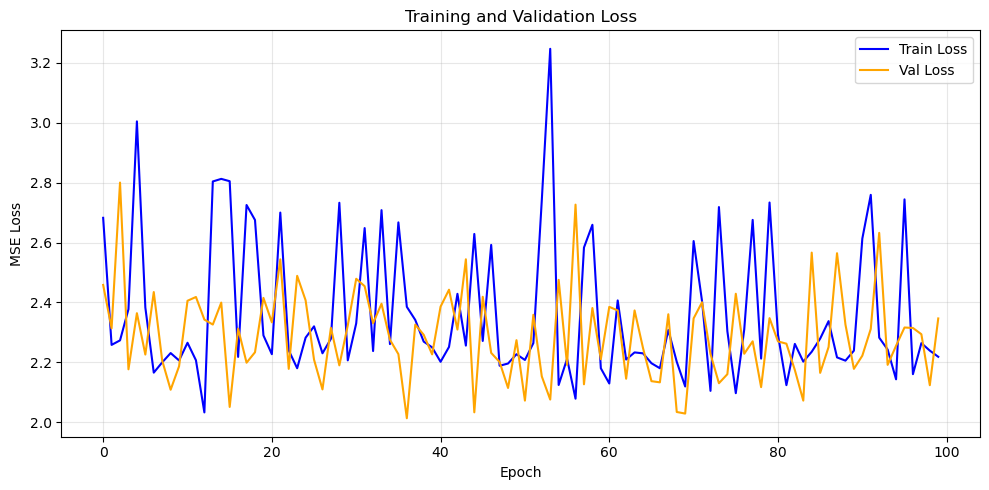

Test Loss: 2.413878


In [12]:
# Plot training curves
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(train_losses, label='Train Loss', color='blue')
ax.plot(val_losses, label='Val Loss', color='orange')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.set_title('Training and Validation Loss')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Evaluate on test set
test_loss = evaluate(model, test_loader, device, MASK_RATIO)
print(f"Test Loss: {test_loss:.6f}")


# 3. Extract Embeddings & Create Sequence Representations

Now we:
1. Extract GAT embeddings for all chirps (without masking)
2. Create non-overlapping 4-gram sequences
3. Add learned positional encodings to distinguish position within each sequence
4. Create final sequence embeddings via MLP fusion


In [13]:
@torch.no_grad()
def extract_embeddings(model, graphs, device):
    """
    Extract GAT embeddings for all nodes in all graphs.
    
    Returns:
        List of embedding tensors, one per graph
    """
    model.eval()
    all_embeddings = []
    
    for graph in tqdm(graphs, desc="Extracting embeddings"):
        graph = graph.to(device)
        
        # Get embeddings without masking
        h = model.encode(graph.x, graph.edge_index, graph.edge_attr)
        all_embeddings.append(h.cpu())
    
    return all_embeddings

# Extract embeddings for all graphs
all_embeddings = extract_embeddings(model, graphs, device)

print(f"Extracted embeddings for {len(all_embeddings)} recordings")
print(f"First recording: {all_embeddings[0].shape} (num_chirps, embedding_dim)")
print(f"Total chirps with embeddings: {sum(e.shape[0] for e in all_embeddings)}")


Extracting embeddings:   0%|          | 0/2929 [00:00<?, ?it/s]

Extracting embeddings: 100%|██████████| 2929/2929 [00:52<00:00, 55.84it/s] 

Extracted embeddings for 2929 recordings
First recording: torch.Size([8, 32]) (num_chirps, embedding_dim)
Total chirps with embeddings: 41774


### Create Non-Overlapping 4-Grams with Positional Encodings

We extract non-overlapping sequences of 4 consecutive chirps from each recording, add learned positional encodings, and fuse them into a single 32-dimensional sequence embedding.


In [14]:
class SequenceEmbedder(nn.Module):
    """
    Creates sequence embeddings from 4-gram chirp embeddings.
    
    Architecture:
        1. Add learned positional encodings to each chirp position (0-3)
        2. Concatenate 4 chirps: [h'_1 || h'_2 || h'_3 || h'_4] -> ℝ^128
        3. MLP fusion: ℝ^128 -> ℝ^32
    """
    
    def __init__(self, embed_dim=32, seq_len=4, output_dim=32):
        super().__init__()
        
        self.embed_dim = embed_dim
        self.seq_len = seq_len
        
        # Learned positional encodings for positions 0, 1, 2, 3
        self.positional_embeddings = nn.Embedding(seq_len, embed_dim)
        
        # MLP to fuse concatenated embeddings
        concat_dim = embed_dim * seq_len  # 32 * 4 = 128
        self.fusion_mlp = nn.Sequential(
            nn.Linear(concat_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(64, output_dim)
        )
    
    def forward(self, chirp_embeddings):
        """
        Args:
            chirp_embeddings: [batch_size, seq_len, embed_dim] or [seq_len, embed_dim]
            
        Returns:
            sequence_embeddings: [batch_size, output_dim] or [output_dim]
        """
        # Handle both batched and single inputs
        single_input = chirp_embeddings.dim() == 2
        if single_input:
            chirp_embeddings = chirp_embeddings.unsqueeze(0)
        
        batch_size = chirp_embeddings.shape[0]
        
        # Get positional encodings [seq_len, embed_dim]
        positions = torch.arange(self.seq_len, device=chirp_embeddings.device)
        pos_enc = self.positional_embeddings(positions)  # [seq_len, embed_dim]
        
        # Add positional encodings to chirp embeddings
        # chirp_embeddings: [batch_size, seq_len, embed_dim]
        # pos_enc: [seq_len, embed_dim] -> broadcast to [batch_size, seq_len, embed_dim]
        h_prime = chirp_embeddings + pos_enc.unsqueeze(0)
        
        # Concatenate all chirps: [batch_size, seq_len * embed_dim]
        h_concat = h_prime.view(batch_size, -1)
        
        # Fuse through MLP
        sequence_emb = self.fusion_mlp(h_concat)
        
        if single_input:
            sequence_emb = sequence_emb.squeeze(0)
        
        return sequence_emb


# Initialize sequence embedder
seq_embedder = SequenceEmbedder(embed_dim=32, seq_len=4, output_dim=32).to(device)
print(f"Sequence Embedder:\n{seq_embedder}")
print(f"Parameters: {sum(p.numel() for p in seq_embedder.parameters()):,}")


Sequence Embedder:
SequenceEmbedder(
  (positional_embeddings): Embedding(4, 32)
  (fusion_mlp): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
  )
)
Parameters: 10,464


In [15]:
def extract_4grams(embeddings_list, file_ids, seq_len=4):
    """
    Extract non-overlapping 4-grams from each recording.
    
    Args:
        embeddings_list: List of [num_chirps, embed_dim] tensors
        file_ids: List of file IDs corresponding to each recording
        seq_len: Length of each sequence (default 4)
        
    Returns:
        sequences: Tensor of shape [num_sequences, seq_len, embed_dim]
        metadata: List of dicts with (file_id, start_idx) for each sequence
    """
    all_sequences = []
    metadata = []
    
    for embeddings, file_id in zip(embeddings_list, file_ids):
        num_chirps = embeddings.shape[0]
        num_sequences = num_chirps // seq_len
        
        for i in range(num_sequences):
            start_idx = i * seq_len
            end_idx = start_idx + seq_len
            
            # Extract 4 consecutive chirps
            seq = embeddings[start_idx:end_idx]  # [4, 32]
            all_sequences.append(seq)
            
            # Store metadata for traceability
            metadata.append({
                'file_id': file_id,
                'start_idx': start_idx,
                'end_idx': end_idx
            })
    
    # Stack into single tensor
    sequences = torch.stack(all_sequences)  # [num_sequences, seq_len, embed_dim]
    
    return sequences, metadata


# Extract 4-grams
sequences_tensor, sequence_metadata = extract_4grams(all_embeddings, file_ids, seq_len=4)

print(f"Extracted {len(sequences_tensor)} non-overlapping 4-grams")
print(f"Sequences tensor shape: {sequences_tensor.shape}")
print(f"\nExample metadata for first 3 sequences:")
for i, meta in enumerate(sequence_metadata[:3]):
    print(f"  Sequence {i}: FileID={meta['file_id']}, Chirps {meta['start_idx']}-{meta['end_idx']-1}")


Extracted 9422 non-overlapping 4-grams
Sequences tensor shape: torch.Size([9422, 4, 32])

Example metadata for first 3 sequences:
  Sequence 0: FileID=7, Chirps 0-3
  Sequence 1: FileID=7, Chirps 4-7
  Sequence 2: FileID=18, Chirps 0-3


In [16]:
# Create final sequence embeddings with positional encodings
seq_embedder.eval()

with torch.no_grad():
    # Process in batches for efficiency
    batch_size = 256
    all_sequence_embeddings = []
    
    for i in range(0, len(sequences_tensor), batch_size):
        batch = sequences_tensor[i:i+batch_size].to(device)
        seq_emb = seq_embedder(batch)
        all_sequence_embeddings.append(seq_emb.cpu())
    
    # Concatenate all batches
    final_sequence_embeddings = torch.cat(all_sequence_embeddings, dim=0)

print(f"Final sequence embeddings shape: {final_sequence_embeddings.shape}")
print(f"Each 4-gram is now represented as a {final_sequence_embeddings.shape[1]}-dimensional vector")
print(f"\nFirst 3 sequence embeddings (first 5 dims):")
print(final_sequence_embeddings[:3, :5])


Final sequence embeddings shape: torch.Size([9422, 32])
Each 4-gram is now represented as a 32-dimensional vector

First 3 sequence embeddings (first 5 dims):
tensor([[ 1.3438e-01,  2.9292e-01, -1.7594e-01, -1.2768e-01, -3.0261e-02],
        [ 1.3889e-01,  2.9926e-01, -1.7713e-01, -1.2994e-01, -2.7946e-04],
        [ 1.0074e-01,  3.2036e-01, -1.9370e-01, -4.2451e-02, -3.0699e-03]])


### Summary

We now have:
- **GAT embeddings**: 32-dimensional contextual embeddings for each chirp
- **Sequence embeddings**: 32-dimensional representations for each 4-gram sequence

These sequence embeddings are ready for clustering (e.g., HDBSCAN) to identify frequently occurring patterns in bat vocalizations.


In [17]:
# Save embeddings for later use
embeddings_data = {
    'sequence_embeddings': final_sequence_embeddings.numpy(),
    'sequence_metadata': sequence_metadata,
    'chirp_embeddings': [e.numpy() for e in all_embeddings],
    'file_ids': file_ids
}

# You can save to disk if needed:
# torch.save(embeddings_data, 'bat_chirp_embeddings.pt')

print("Embeddings ready for clustering!")
print(f"Total 4-gram sequences: {len(final_sequence_embeddings)}")
print(f"Embedding dimension: {final_sequence_embeddings.shape[1]}")


Embeddings ready for clustering!
Total 4-gram sequences: 9422
Embedding dimension: 32


# 4. Clustering & Evaluation

We use HDBSCAN to cluster the sequence embeddings into groups of acoustically similar 4-gram patterns. We evaluate the clustering using:
1. **Silhouette Score**: Measures how similar sequences are to their own cluster vs. other clusters
2. **Same-Recording Coherence**: Measures if sequences from the same recording tend to cluster together
3. **Cluster Purity by Recording**: Measures if clusters contain sequences from diverse recordings (good) or single recordings (potentially overfitting)


In [18]:
# Install hdbscan if needed
!pip install hdbscan umap-learn --quiet

import hdbscan
import umap
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

print("Clustering libraries loaded successfully!")


Clustering libraries loaded successfully!


### HDBSCAN Clustering

HDBSCAN (Hierarchical Density-Based Spatial Clustering of Applications with Noise) is ideal for our data because:
- It can find clusters of varying density
- It labels outliers as noise (cluster -1)
- It doesn't require specifying the number of clusters upfront


In [19]:
# Convert embeddings to numpy for clustering
embeddings_np = final_sequence_embeddings.numpy()

# HDBSCAN clustering
# min_cluster_size: minimum number of samples in a cluster
# min_samples: how conservative the clustering is (higher = more noise points)
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=15,      # Minimum 15 sequences to form a cluster
    min_samples=5,            # Conservative clustering
    metric='euclidean',
    cluster_selection_method='eom'  # Excess of Mass - finds more clusters
)

cluster_labels = clusterer.fit_predict(embeddings_np)

# Analyze cluster distribution
unique_labels, counts = np.unique(cluster_labels, return_counts=True)
n_clusters = len(unique_labels[unique_labels >= 0])  # Exclude noise (-1)
n_noise = (cluster_labels == -1).sum()

print(f"HDBSCAN Clustering Results:")
print(f"  Number of clusters: {n_clusters}")
print(f"  Noise points: {n_noise} ({100*n_noise/len(cluster_labels):.1f}%)")
print(f"  Clustered points: {len(cluster_labels) - n_noise} ({100*(len(cluster_labels)-n_noise)/len(cluster_labels):.1f}%)")

# Show cluster sizes (excluding noise)
print(f"\nCluster sizes (top 10):")
cluster_counts = Counter(cluster_labels)
for label, count in cluster_counts.most_common(11):
    if label >= 0:
        print(f"  Cluster {label}: {count} sequences")


/opt/anaconda3/envs/BatGPT/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/anaconda3/envs/BatGPT/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


HDBSCAN Clustering Results:
  Number of clusters: 2
  Noise points: 8548 (90.7%)
  Clustered points: 874 (9.3%)

Cluster sizes (top 10):
  Cluster 1: 733 sequences
  Cluster 0: 141 sequences


### Clustering Evaluation Metrics

We evaluate the clustering quality using multiple metrics:

1. **Silhouette Score** (-1 to 1): How similar points are to their cluster vs other clusters
2. **Calinski-Harabasz Index** (higher is better): Ratio of between-cluster to within-cluster variance
3. **Same-Recording Coherence**: Do sequences from the same recording tend to be near each other?
4. **Recording Diversity per Cluster**: Are clusters capturing patterns across recordings (good) or just single recordings (potentially overfitting)?


In [20]:
# Extract file_ids for each sequence
sequence_file_ids = np.array([meta['file_id'] for meta in sequence_metadata])

# Only compute metrics on clustered points (exclude noise)
clustered_mask = cluster_labels >= 0
clustered_embeddings = embeddings_np[clustered_mask]
clustered_labels = cluster_labels[clustered_mask]
clustered_file_ids = sequence_file_ids[clustered_mask]

print("=" * 60)
print("CLUSTERING EVALUATION METRICS")
print("=" * 60)

# 1. Silhouette Score
if len(np.unique(clustered_labels)) > 1:
    silhouette = silhouette_score(clustered_embeddings, clustered_labels)
    print(f"\n1. Silhouette Score: {silhouette:.4f}")
    print(f"   Interpretation: {'Good' if silhouette > 0.5 else 'Moderate' if silhouette > 0.25 else 'Weak'} cluster separation")
else:
    print("\n1. Silhouette Score: Cannot compute (only 1 cluster)")

# 2. Calinski-Harabasz Index (Variance Ratio Criterion)
if len(np.unique(clustered_labels)) > 1:
    calinski = calinski_harabasz_score(clustered_embeddings, clustered_labels)
    print(f"\n2. Calinski-Harabasz Index: {calinski:.2f}")
    print(f"   (Higher is better - measures between-cluster vs within-cluster variance)")

# 3. Same-Recording Coherence
# For each recording with multiple sequences, compute the fraction that are in the same cluster
print(f"\n3. Same-Recording Coherence:")
recording_coherence = []
for fid in np.unique(sequence_file_ids):
    mask = sequence_file_ids == fid
    labels_for_recording = cluster_labels[mask]
    # Exclude noise
    valid_labels = labels_for_recording[labels_for_recording >= 0]
    if len(valid_labels) > 1:
        # What fraction of pairs are in the same cluster?
        most_common_cluster = Counter(valid_labels).most_common(1)[0][0]
        coherence = (valid_labels == most_common_cluster).mean()
        recording_coherence.append(coherence)

if recording_coherence:
    avg_coherence = np.mean(recording_coherence)
    print(f"   Average coherence: {avg_coherence:.4f}")
    print(f"   (Higher = sequences from same recording tend to cluster together)")
    print(f"   Interpretation: {100*avg_coherence:.1f}% of sequences stay with their recording's dominant cluster")

# 4. Recording Diversity per Cluster
print(f"\n4. Recording Diversity per Cluster:")
cluster_recording_diversity = []
for label in np.unique(clustered_labels):
    mask = clustered_labels == label
    file_ids_in_cluster = clustered_file_ids[mask]
    n_unique_recordings = len(np.unique(file_ids_in_cluster))
    n_sequences = mask.sum()
    diversity = n_unique_recordings / n_sequences  # Ratio of unique recordings to sequences
    cluster_recording_diversity.append({
        'cluster': label,
        'n_sequences': n_sequences,
        'n_recordings': n_unique_recordings,
        'diversity': diversity
    })

# Sort by cluster size
cluster_recording_diversity.sort(key=lambda x: x['n_sequences'], reverse=True)

print(f"   Top 5 clusters by size:")
for info in cluster_recording_diversity[:5]:
    print(f"   Cluster {info['cluster']}: {info['n_sequences']} sequences from {info['n_recordings']} recordings")

avg_diversity = np.mean([c['n_recordings'] for c in cluster_recording_diversity])
print(f"\n   Average recordings per cluster: {avg_diversity:.1f}")
print(f"   (Higher diversity = clusters capture patterns across multiple recordings - GOOD)")
print(f"   (Low diversity = clusters might just be grouping same-recording sequences - potentially overfitting)")


CLUSTERING EVALUATION METRICS

1. Silhouette Score: 0.4686
   Interpretation: Moderate cluster separation

2. Calinski-Harabasz Index: 602.24
   (Higher is better - measures between-cluster vs within-cluster variance)

3. Same-Recording Coherence:
   Average coherence: 0.9961
   (Higher = sequences from same recording tend to cluster together)
   Interpretation: 99.6% of sequences stay with their recording's dominant cluster

4. Recording Diversity per Cluster:
   Top 5 clusters by size:
   Cluster 1: 733 sequences from 464 recordings
   Cluster 0: 141 sequences from 122 recordings

   Average recordings per cluster: 293.0
   (Higher diversity = clusters capture patterns across multiple recordings - GOOD)
   (Low diversity = clusters might just be grouping same-recording sequences - potentially overfitting)


### Cluster Visualization with UMAP

We use UMAP to project the 32-dimensional sequence embeddings to 2D for visualization.


Computing UMAP projection (this may take a minute)...


/opt/anaconda3/envs/BatGPT/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


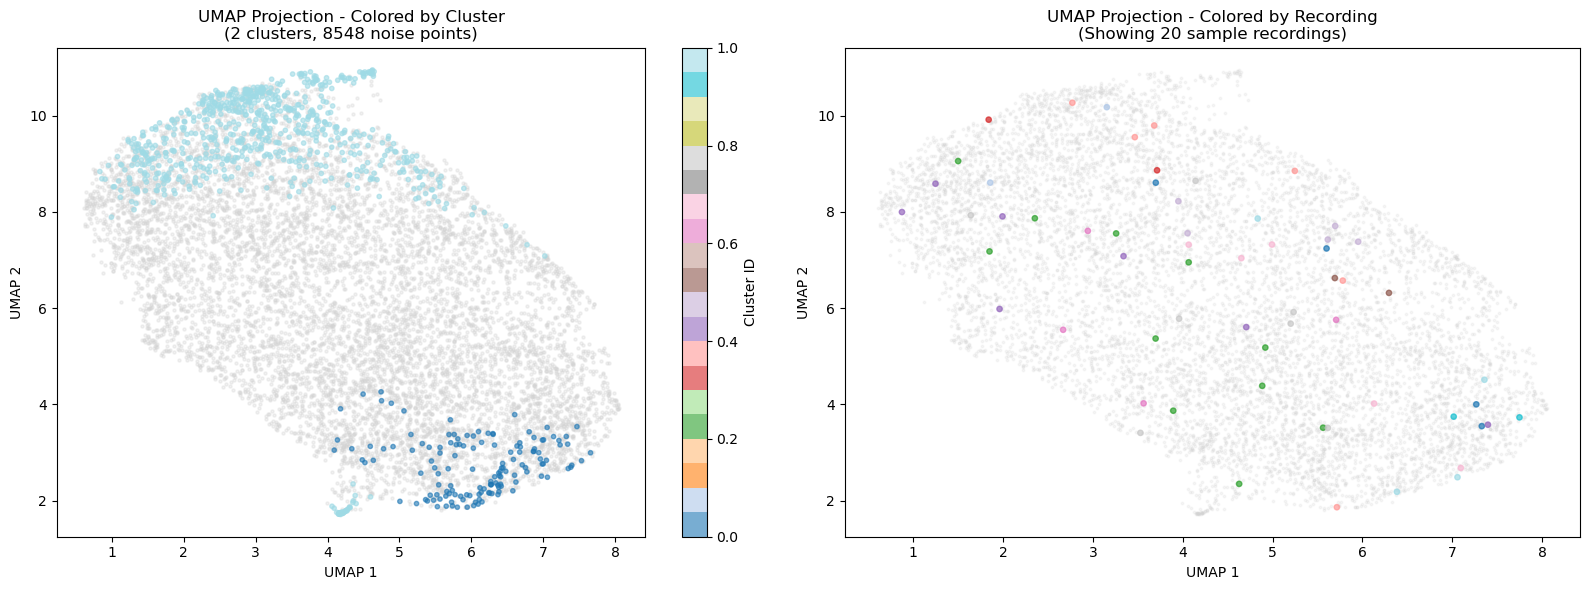


Visualization complete!


In [21]:
# UMAP dimensionality reduction for visualization
print("Computing UMAP projection (this may take a minute)...")
reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    metric='euclidean',
    random_state=42
)
embeddings_2d = reducer.fit_transform(embeddings_np)

# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Colored by cluster
ax1 = axes[0]
# Noise points in gray
noise_mask = cluster_labels == -1
ax1.scatter(embeddings_2d[noise_mask, 0], embeddings_2d[noise_mask, 1], 
            c='lightgray', s=5, alpha=0.3, label='Noise')
# Clustered points
scatter = ax1.scatter(embeddings_2d[~noise_mask, 0], embeddings_2d[~noise_mask, 1], 
                      c=cluster_labels[~noise_mask], cmap='tab20', s=10, alpha=0.6)
ax1.set_title(f'UMAP Projection - Colored by Cluster\n({n_clusters} clusters, {n_noise} noise points)')
ax1.set_xlabel('UMAP 1')
ax1.set_ylabel('UMAP 2')
plt.colorbar(scatter, ax=ax1, label='Cluster ID')

# Plot 2: Colored by recording (sample for visibility)
ax2 = axes[1]
# Use a subset of recordings for visibility
unique_recordings = np.unique(sequence_file_ids)
n_recordings_to_show = min(20, len(unique_recordings))
sample_recordings = np.random.choice(unique_recordings, n_recordings_to_show, replace=False)
sample_mask = np.isin(sequence_file_ids, sample_recordings)

# Gray background for non-sample
ax2.scatter(embeddings_2d[~sample_mask, 0], embeddings_2d[~sample_mask, 1], 
            c='lightgray', s=3, alpha=0.2)
# Colored sample recordings
scatter2 = ax2.scatter(embeddings_2d[sample_mask, 0], embeddings_2d[sample_mask, 1], 
                       c=sequence_file_ids[sample_mask], cmap='tab20', s=15, alpha=0.7)
ax2.set_title(f'UMAP Projection - Colored by Recording\n(Showing {n_recordings_to_show} sample recordings)')
ax2.set_xlabel('UMAP 1')
ax2.set_ylabel('UMAP 2')

plt.tight_layout()
plt.show()

print("\nVisualization complete!")


# 5. Feature Importance Analysis

We analyze which acoustic features are most important for the clustering by:
1. Computing cluster centroids in embedding space
2. Finding PCA components that vary most between clusters
3. Mapping back to original features using PCA loadings


In [22]:
# Get original feature names (the columns that went into PCA)
original_feature_names = list(df_features.columns)
print(f"Number of original features: {len(original_feature_names)}")
print(f"First 10 features: {original_feature_names[:10]}")

# PCA components: pca.components_ has shape [n_components, n_features]
# Each row is a principal component, each column is an original feature
pca_loadings = pca.components_  # [32, 83]
print(f"\nPCA loadings shape: {pca_loadings.shape}")
print(f"  - {pca_loadings.shape[0]} PCA components")
print(f"  - {pca_loadings.shape[1]} original features")


Number of original features: 83
First 10 features: ['CallsPerSec', 'CallDuration', 'Fc', 'HiFreq', 'LowFreq', 'Bndwdth', 'FreqMaxPwr', 'TimeFromMaxToFc', 'FreqKnee', 'PrcntKneeDur']

PCA loadings shape: (32, 83)
  - 32 PCA components
  - 83 original features


### PCA Component Importance for Clustering

We compute how much each PCA component varies across clusters (high variance = important for distinguishing clusters).


In [23]:
# To analyze which PCA components matter for clustering, we need to trace back
# from sequence embeddings to the original chirp PCA features

# For each cluster, get the original PCA features of the chirps in that cluster
def get_cluster_pca_features(cluster_label, cluster_labels, sequence_metadata, df_pca, seq_len=4):
    """Get all PCA features for chirps belonging to sequences in a cluster."""
    mask = cluster_labels == cluster_label
    pca_features = []
    
    for idx in np.where(mask)[0]:
        meta = sequence_metadata[idx]
        file_id = meta['file_id']
        start_idx = meta['start_idx']
        end_idx = meta['end_idx']
        
        # Get the original PCA features for these chirps
        file_data = df_pca[df_pca['FileID'] == file_id].iloc[start_idx:end_idx]
        pca_cols = [c for c in file_data.columns if c.startswith('PC')]
        pca_features.append(file_data[pca_cols].values)
    
    return np.vstack(pca_features)

# Compute cluster centroids in PCA space
cluster_pca_centroids = {}
for label in np.unique(clustered_labels):
    if label >= 0:  # Skip noise
        features = get_cluster_pca_features(label, cluster_labels, sequence_metadata, df_pca)
        cluster_pca_centroids[label] = features.mean(axis=0)

# Stack centroids into matrix
centroid_matrix = np.vstack([cluster_pca_centroids[l] for l in sorted(cluster_pca_centroids.keys())])
print(f"Cluster centroids shape: {centroid_matrix.shape}")

# Compute variance of each PCA component across cluster centroids
pca_component_variance = centroid_matrix.var(axis=0)
pca_component_importance = pca_component_variance / pca_component_variance.sum()

# Rank PCA components by importance
pca_importance_ranking = np.argsort(pca_component_importance)[::-1]

print(f"\nTop 10 most important PCA components for cluster differentiation:")
print("-" * 50)
for rank, pc_idx in enumerate(pca_importance_ranking[:10]):
    importance = pca_component_importance[pc_idx]
    variance_explained = pca.explained_variance_ratio_[pc_idx]
    print(f"  {rank+1}. PC{pc_idx+1}: {100*importance:.2f}% cluster variance (explains {100*variance_explained:.2f}% of original variance)")


Cluster centroids shape: (2, 32)

Top 10 most important PCA components for cluster differentiation:
--------------------------------------------------
  1. PC1: 95.76% cluster variance (explains 26.27% of original variance)
  2. PC3: 1.33% cluster variance (explains 10.52% of original variance)
  3. PC2: 1.14% cluster variance (explains 10.77% of original variance)
  4. PC4: 0.54% cluster variance (explains 5.18% of original variance)
  5. PC6: 0.26% cluster variance (explains 3.41% of original variance)
  6. PC11: 0.21% cluster variance (explains 1.96% of original variance)
  7. PC7: 0.21% cluster variance (explains 3.21% of original variance)
  8. PC31: 0.10% cluster variance (explains 0.55% of original variance)
  9. PC32: 0.08% cluster variance (explains 0.51% of original variance)
  10. PC10: 0.07% cluster variance (explains 2.19% of original variance)


### Mapping Back to Original Features

Using the PCA loadings, we identify which original acoustic features contribute most to the important PCA components.


In [24]:
# Compute weighted importance of original features
# Weight each PCA component's loadings by its importance for clustering

# weighted_loadings[i] = sum over all PCA components of (importance[pc] * |loading[pc, i]|)
weighted_feature_importance = np.zeros(len(original_feature_names))

for pc_idx in range(len(pca_component_importance)):
    pc_importance = pca_component_importance[pc_idx]
    pc_loadings = np.abs(pca_loadings[pc_idx])  # Absolute value of loadings
    weighted_feature_importance += pc_importance * pc_loadings

# Normalize
weighted_feature_importance = weighted_feature_importance / weighted_feature_importance.sum()

# Rank features by importance
feature_importance_ranking = np.argsort(weighted_feature_importance)[::-1]

print("=" * 70)
print("MOST IMPORTANT ORIGINAL ACOUSTIC FEATURES FOR CLUSTERING")
print("=" * 70)
print("\nTop 20 features (weighted by PCA component importance for clustering):")
print("-" * 70)

feature_importance_df = pd.DataFrame({
    'Feature': [original_feature_names[i] for i in feature_importance_ranking],
    'Importance': [weighted_feature_importance[i] for i in feature_importance_ranking]
})

for rank, idx in enumerate(feature_importance_ranking[:20]):
    feature_name = original_feature_names[idx]
    importance = weighted_feature_importance[idx]
    print(f"  {rank+1:2d}. {feature_name:40s} {100*importance:.3f}%")

# Save to dataframe for easy access
feature_importance_df.to_csv('feature_importance.csv', index=False)
print(f"\n(Full feature importance saved to 'feature_importance.csv')")


MOST IMPORTANT ORIGINAL ACOUSTIC FEATURES FOR CLUSTERING

Top 20 features (weighted by PCA component importance for clustering):
----------------------------------------------------------------------
   1. TotalSlope                               2.524%
   2. CummNmlzdSlp                             2.457%
   3. FFwd15dB                                 2.422%
   4. FFwd20dB                                 2.397%
   5. HiFtoFcExp                               2.366%
   6. HiFreq                                   2.320%
   7. StartF                                   2.318%
   8. FreqCtr                                  2.239%
   9. FFwd5dB                                  2.235%
  10. Bndw15dB                                 2.208%
  11. HiFtoKnSlope                             2.172%
  12. 1st5to15kHzSlp                           2.158%
  13. Bndw20dB                                 2.157%
  14. PreFc3000                                2.136%
  15. SteepestSlope                         

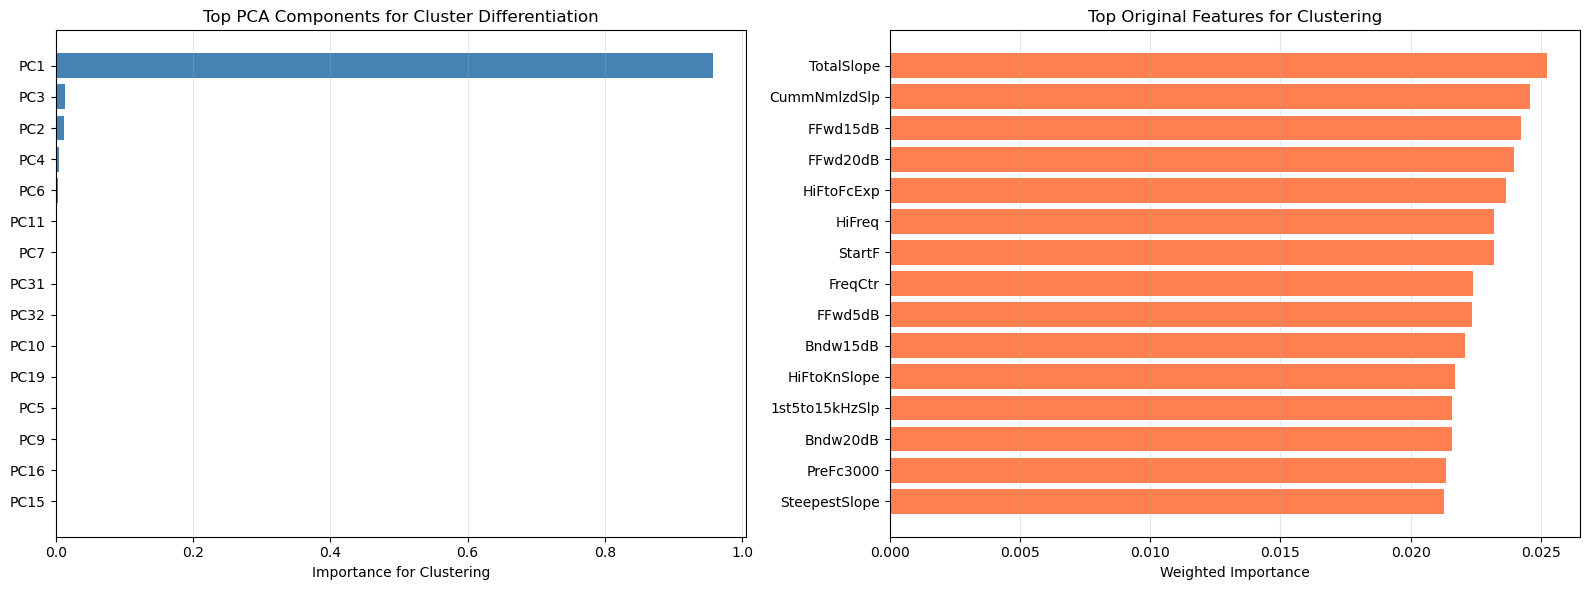


FEATURE IMPORTANCE BY CATEGORY

Importance by feature category:
  Other               : 56.98%
  Frequency           : 16.46%
  Slope/Rate          : 15.24%
  Duration/Time       : 7.85%
  Amplitude           : 3.47%


In [25]:
# Visualize feature importance
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: PCA component importance for clustering
ax1 = axes[0]
top_n_pca = 15
top_pca_indices = pca_importance_ranking[:top_n_pca]
top_pca_names = [f'PC{i+1}' for i in top_pca_indices]
top_pca_importance = [pca_component_importance[i] for i in top_pca_indices]

bars1 = ax1.barh(range(top_n_pca), top_pca_importance[::-1], color='steelblue')
ax1.set_yticks(range(top_n_pca))
ax1.set_yticklabels(top_pca_names[::-1])
ax1.set_xlabel('Importance for Clustering')
ax1.set_title('Top PCA Components for Cluster Differentiation')
ax1.grid(axis='x', alpha=0.3)

# Plot 2: Original feature importance
ax2 = axes[1]
top_n_features = 15
top_feature_indices = feature_importance_ranking[:top_n_features]
top_feature_names = [original_feature_names[i][:30] for i in top_feature_indices]  # Truncate long names
top_feature_importance = [weighted_feature_importance[i] for i in top_feature_indices]

bars2 = ax2.barh(range(top_n_features), top_feature_importance[::-1], color='coral')
ax2.set_yticks(range(top_n_features))
ax2.set_yticklabels(top_feature_names[::-1])
ax2.set_xlabel('Weighted Importance')
ax2.set_title('Top Original Features for Clustering')
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# Group features by category (frequency, duration, etc.) based on name patterns
print("\n" + "=" * 70)
print("FEATURE IMPORTANCE BY CATEGORY")
print("=" * 70)

category_importance = {}
for idx, name in enumerate(original_feature_names):
    importance = weighted_feature_importance[idx]
    
    # Categorize based on common patterns in feature names
    if 'Freq' in name or 'freq' in name or 'Hz' in name:
        cat = 'Frequency'
    elif 'Dur' in name or 'dur' in name or 'Time' in name or 'time' in name:
        cat = 'Duration/Time'
    elif 'Slope' in name or 'slope' in name:
        cat = 'Slope/Rate'
    elif 'Amp' in name or 'amp' in name:
        cat = 'Amplitude'
    elif 'BW' in name or 'Bandwidth' in name:
        cat = 'Bandwidth'
    elif 'Power' in name or 'Energy' in name:
        cat = 'Power/Energy'
    else:
        cat = 'Other'
    
    category_importance[cat] = category_importance.get(cat, 0) + importance

# Sort and display
sorted_categories = sorted(category_importance.items(), key=lambda x: x[1], reverse=True)
print("\nImportance by feature category:")
for cat, imp in sorted_categories:
    print(f"  {cat:20s}: {100*imp:.2f}%")


# 6. Cluster Inspection

Examine specific clusters to understand what patterns they capture.


In [26]:
def inspect_cluster(cluster_id, cluster_labels, sequence_metadata, df_pca, original_feature_names, 
                     pca_loadings, n_sequences=5):
    """
    Inspect a specific cluster: show representative sequences and their acoustic characteristics.
    """
    mask = cluster_labels == cluster_id
    cluster_indices = np.where(mask)[0]
    
    print(f"\n{'='*70}")
    print(f"CLUSTER {cluster_id} INSPECTION")
    print(f"{'='*70}")
    print(f"Total sequences in cluster: {len(cluster_indices)}")
    
    # Get file IDs in this cluster
    file_ids_in_cluster = [sequence_metadata[i]['file_id'] for i in cluster_indices]
    unique_files = np.unique(file_ids_in_cluster)
    print(f"From {len(unique_files)} different recordings")
    
    # Get PCA features for this cluster
    cluster_pca = get_cluster_pca_features(cluster_id, cluster_labels, sequence_metadata, df_pca)
    cluster_mean = cluster_pca.mean(axis=0)
    
    # Compare to global mean
    global_pca_mean = df_pca[[c for c in df_pca.columns if c.startswith('PC')]].mean().values
    
    print(f"\nPCA components that differ most from global average:")
    print("-" * 50)
    
    diff = cluster_mean - global_pca_mean
    diff_ranking = np.argsort(np.abs(diff))[::-1]
    
    for i, pc_idx in enumerate(diff_ranking[:5]):
        direction = "↑ higher" if diff[pc_idx] > 0 else "↓ lower"
        print(f"  PC{pc_idx+1}: {diff[pc_idx]:+.3f} ({direction} than average)")
    
    # Map to original features
    print(f"\nTop contributing original features for this cluster:")
    print("-" * 50)
    
    # Weight the PCA loadings by how much each PC differs from average
    weighted_diff = np.zeros(len(original_feature_names))
    for pc_idx in range(len(diff)):
        weighted_diff += np.abs(diff[pc_idx]) * np.abs(pca_loadings[pc_idx])
    
    top_features = np.argsort(weighted_diff)[::-1][:10]
    for idx in top_features:
        print(f"  - {original_feature_names[idx]}")
    
    return cluster_mean, diff


# Inspect the top 3 largest clusters
print("Inspecting the largest clusters...\n")
largest_clusters = [info['cluster'] for info in cluster_recording_diversity[:3]]

cluster_profiles = {}
for cluster_id in largest_clusters:
    mean, diff = inspect_cluster(
        cluster_id, cluster_labels, sequence_metadata, df_pca, 
        original_feature_names, pca_loadings
    )
    cluster_profiles[cluster_id] = {'mean': mean, 'diff': diff}


Inspecting the largest clusters...


CLUSTER 1 INSPECTION
Total sequences in cluster: 733
From 464 different recordings

PCA components that differ most from global average:
--------------------------------------------------
  PC1: -5.106 (↓ lower than average)
  PC3: -2.950 (↓ lower than average)
  PC2: +0.573 (↑ higher than average)
  PC8: -0.422 (↓ lower than average)
  PC4: -0.399 (↓ lower than average)

Top contributing original features for this cluster:
--------------------------------------------------
  - FFwd5dB
  - Fc
  - FreqCtr
  - FBak5dB
  - FreqLedge
  - HiFtoKnExp
  - HiFtoKnSlope
  - Bndwdth
  - HiFtoFcExp
  - FFwd15dB

CLUSTER 0 INSPECTION
Total sequences in cluster: 141
From 122 different recordings

PCA components that differ most from global average:
--------------------------------------------------
  PC1: +7.476 (↑ higher than average)
  PC3: -1.469 (↓ lower than average)
  PC2: -0.799 (↓ lower than average)
  PC4: +0.549 (↑ higher than average)
  PC6: +0.492 (↑

# Summary

This notebook implemented a complete pipeline for analyzing bat chirp sequences:

1. **Data Preprocessing**: Reduced 83 acoustic features to 32 PCA components
2. **Graph Construction**: Created bidirectional graphs with time-interval edge features
3. **GAT Training**: Self-supervised learning via masked reconstruction
4. **Sequence Embeddings**: Combined 4-gram chirps with positional encodings
5. **Clustering**: HDBSCAN to find acoustically similar patterns
6. **Evaluation**: Silhouette score, recording coherence, and diversity metrics
7. **Feature Importance**: Traced clusters back to original acoustic features

The identified clusters represent potential "phrases" or recurring patterns in bat vocalizations that warrant further biological investigation.


In [27]:
# Save all results
results = {
    # Embeddings
    'sequence_embeddings': final_sequence_embeddings.numpy(),
    'sequence_metadata': sequence_metadata,
    'embeddings_2d': embeddings_2d,
    
    # Clustering
    'cluster_labels': cluster_labels,
    'n_clusters': n_clusters,
    'n_noise': n_noise,
    
    # Metrics
    'silhouette_score': silhouette if 'silhouette' in dir() else None,
    'calinski_harabasz': calinski if 'calinski' in dir() else None,
    'avg_recording_coherence': avg_coherence if 'avg_coherence' in dir() else None,
    
    # Feature importance
    'pca_component_importance': pca_component_importance,
    'feature_importance': weighted_feature_importance,
    'feature_names': original_feature_names,
}

# Save to file
import pickle
with open('clustering_results.pkl', 'wb') as f:
    pickle.dump(results, f)

print("All results saved to 'clustering_results.pkl'")
print("\nQuick access:")
print(f"  - Cluster labels: results['cluster_labels']")
print(f"  - Feature importance: results['feature_importance']")
print(f"  - 2D embeddings for plotting: results['embeddings_2d']")


All results saved to 'clustering_results.pkl'

Quick access:
  - Cluster labels: results['cluster_labels']
  - Feature importance: results['feature_importance']
  - 2D embeddings for plotting: results['embeddings_2d']
